In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.preprocessing import StandardScaler

In [82]:
path = "../data/processed_data.csv"
df = pd.read_csv(path)
df = df.replace([np.inf, -np.inf], np.nan).dropna()
print(f"Shape: {df.shape}, NaNs: {df.isna().sum().sum()}")
df.head()

Shape: (1470, 37), NaNs: 0


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,PerformanceIndex,...,YearsWithCurrManager,RemoteWork,MonthlyIncome,WelfareBenefits,InHouseFacility,ExternalFacility,ExtendedLeave,FlexibleWork,StressSelfReported,StressRating
0,0.448696,2.275186,0.590048,1.401512,-1.013529,-0.888082,-0.938496,-0.660531,-1.231716,1.383138,...,0.245533,-1.484408,-0.859256,-1.326566,-1.216109,-0.645124,-0.581016,-1.107823,-1.162892,4
1,1.323184,-0.439525,-0.913194,-0.493817,-0.152180,-1.863778,-0.938496,0.254625,0.811876,-0.240677,...,0.805990,0.142795,-0.029982,1.326566,0.822295,-0.645124,-0.581016,0.902671,-1.162892,2
2,0.011452,2.275186,0.590048,-0.493817,-0.890479,-0.888082,1.318192,1.169781,0.811876,1.284725,...,-1.155608,-0.670806,0.348985,-0.442189,0.822295,-0.645124,-0.581016,-1.107823,-1.162892,3
3,-0.425792,-0.439525,-0.913194,-0.493817,-0.767430,1.063309,-0.938496,1.169781,-1.231716,-0.486709,...,-1.155608,-0.670806,2.187149,1.326566,0.822295,1.550090,1.721123,0.902671,-1.162892,1
4,-1.081659,-0.439525,0.590048,-0.493817,-0.890479,-1.863778,0.565963,-1.575686,0.811876,-1.274014,...,-0.595151,-0.670806,-1.969845,-0.442189,-1.216109,-0.645124,-0.581016,-1.107823,0.943641,3


In [83]:
class LinearRegressionFromScratch:
    def __init__(self, learning_rate=0.0001, n_iterations=100000):
        self.coef_ = None
        self.intercept_ = None
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations

    def fit(self, X, y):
        m, n = X.shape
        self.coef_ = np.zeros((n, 1)) if y.ndim == 2 else np.zeros(n)
        self.intercept_ = 0.0

        for _ in range(self.n_iterations):
            y_pred = self.predict(X)
            residual = y_pred - y
            intercept_gradient = (2/m) * np.sum(residual)
            coef_gradient = (2/m) * np.dot(X.T, residual)
            intercept_gradient = np.clip(intercept_gradient, -1e6, 1e6)
            coef_gradient = np.clip(coef_gradient, -1e6, 1e6)
            self.intercept_ -= self.learning_rate * intercept_gradient
            self.coef_ -= self.learning_rate * coef_gradient
            if np.any(np.isnan(self.coef_)) or np.isnan(self.intercept_):
                break
        return self

    def predict(self, X):
        return np.dot(X, self.coef_) + self.intercept_

    def get_params(self, deep=True):
        """Get parameters for this estimator (sklearn compatible)."""
        return {'learning_rate': self.learning_rate, 'n_iterations': self.n_iterations}

    def set_params(self, **params):
        """Set parameters for this estimator (sklearn compatible)."""
        for key, value in params.items():
            setattr(self, key, value)
        return self


class GradientBoostingRegressorFromScratch:
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.random_state = random_state
        self.trees = []
        self.initial_prediction = None
        
    def fit(self, X, y):
        np.random.seed(self.random_state)
        self.initial_prediction = np.mean(y)
        predictions = np.full_like(y, self.initial_prediction, dtype=float).flatten()
        
        for i in range(self.n_estimators):
            residuals = y.flatten() - predictions
            weak_learner = LinearRegressionFromScratch(learning_rate=0.01, n_iterations=1000)
            weak_learner.fit(X, residuals.reshape(-1, 1))
            weak_pred = weak_learner.predict(X).flatten()
            predictions += self.learning_rate * weak_pred
            self.trees.append(weak_learner)
    
    def predict(self, X):
        predictions = np.full(X.shape[0], self.initial_prediction, dtype=float)
        for tree in self.trees:
            weak_pred = tree.predict(X).flatten()
            predictions += self.learning_rate * weak_pred
        return predictions

In [84]:
target = 'StressRating'
corrs = df.corr(numeric_only=True)[target].drop(target).abs().sort_values(ascending=False)
best_feature = corrs.index[0]

X = df.drop(columns=[target])
y = df[target].values.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
def train_and_evaluate(model, X_train_data, X_test_data, y_train_data, y_test_data):
    """Train model and calculate metrics."""
    model.fit(X_train_data, y_train_data)
    y_pred = model.predict(X_test_data)
    mse = mean_squared_error(y_test_data, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_data, y_pred)
    return {'mse': mse, 'rmse': rmse, 'r2': r2, 'y_pred': y_pred}

def plot_prediction(ax, y_actual_sorted, y_pred, color, title, target_var):
    """Plot actual vs predicted on given axes."""
    sort_idx = np.argsort(y_actual_sorted.flatten())
    y_pred_sorted = y_pred.flatten()[sort_idx]
    y_act_sorted = y_actual_sorted.flatten()[sort_idx]
    ax.plot(range(len(y_act_sorted)), y_act_sorted, 'o-', color='#2196F3', markersize=3, alpha=0.7, label='Actual')
    ax.plot(range(len(y_pred_sorted)), y_pred_sorted, 'o-', color=color, markersize=3, alpha=0.7, label='Predicted')
    ax.fill_between(range(len(y_act_sorted)), y_act_sorted, y_pred_sorted, alpha=0.15, color='gray')
    ax.set(xlabel="Sample", ylabel=target_var, title=title)
    ax.legend()

def plot_comparison(axes_list, y_actual, predictions_dict, y_test_data, target_name):
    """Generic comparison plotter for 2+ subplots."""
    sort_idx = y_test_data.flatten().argsort()
    y_actual_sorted = y_test_data.flatten()[sort_idx]
    
    colors = ['#FF5722', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4']
    for ax_idx, (name, (y_pred, color), title) in enumerate(zip(predictions_dict.keys(), 
                                                                   zip(predictions_dict.values(), colors), 
                                                                   predictions_dict.keys())):
        if ax_idx >= len(axes_list.flat):
            break
        ax = axes_list.flat[ax_idx]
        y_pred_sorted = y_pred.flatten()[sort_idx]
        ax.plot(range(len(y_actual_sorted)), y_actual_sorted, 'o-', color='#2196F3', 
                markersize=3, alpha=0.7, label='Actual')
        ax.plot(range(len(y_pred_sorted)), y_pred_sorted, 'o-', color=color, 
                markersize=3, alpha=0.7, label='Predicted')
        ax.fill_between(range(len(y_actual_sorted)), y_actual_sorted, y_pred_sorted, alpha=0.15)
        ax.set(xlabel="Sample", ylabel=target_name)
        ax.legend()
        asdjkfaldskskdfakl;djfadfkalsdjffkasdfakldfadafasdddddddddddd

In [86]:
# Simple Linear Regression: Best single feature
X_train_simple = X_train[[best_feature]].values
X_test_simple = X_test[[best_feature]].values

model_simple_scratch = LinearRegressionFromScratch(learning_rate=0.001, n_iterations=100000)
model_simple_lib = LinearRegression()

results_simple = {
    'From Scratch': train_and_evaluate(model_simple_scratch, X_train_simple, X_test_simple, y_train, y_test),
    'Sklearn': train_and_evaluate(model_simple_lib, X_train_simple, X_test_simple, y_train, y_test)
}

r2_simple_scratch = results_simple['From Scratch']['r2']
r2_simple_lib = results_simple['Sklearn']['r2']
y_pred_simple_scratch = results_simple['From Scratch']['y_pred']
y_pred_simple_lib = results_simple['Sklearn']['y_pred']

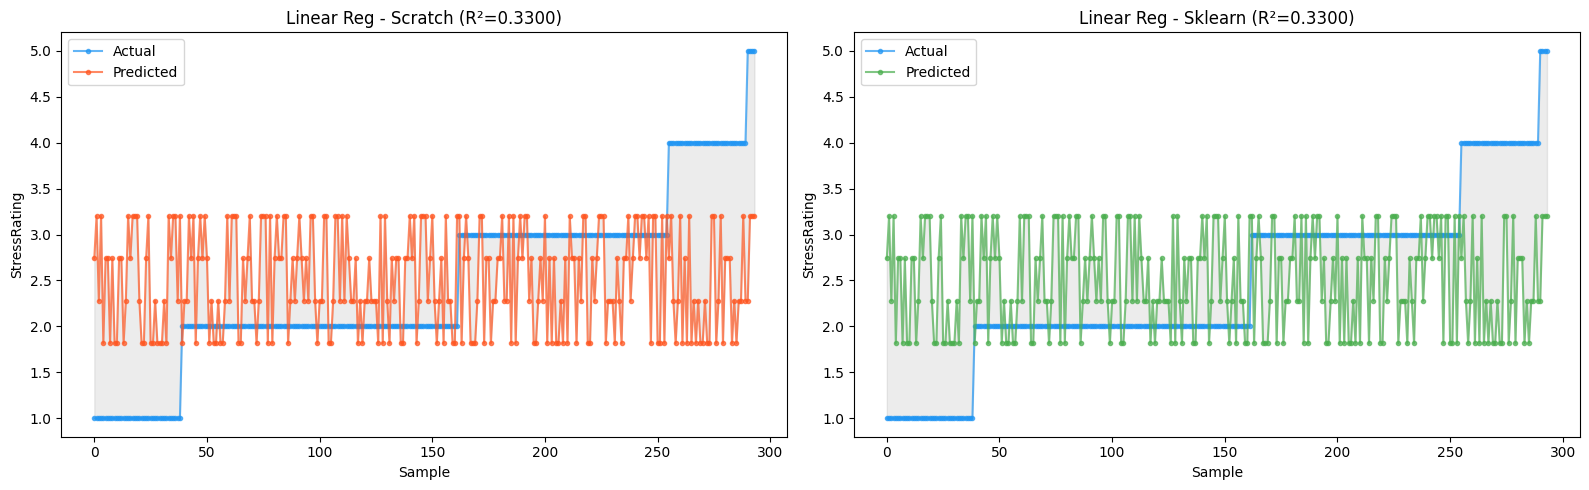

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sort_idx = y_test.flatten().argsort()
y_actual_sorted = y_test.flatten()[sort_idx]

for ax, key, color, title_suffix in zip(axes, ['From Scratch', 'Sklearn'], ['#FF5722', '#4CAF50'], ['Scratch', 'Sklearn']):
    y_pred = results_simple[key]['y_pred']
    r2_val = results_simple[key]['r2']
    plot_prediction(ax, y_actual_sorted, y_pred, color, f"Linear Reg - {title_suffix} (R²={r2_val:.4f})", target)

plt.tight_layout()
plt.show()

In [ ]:
var_ratio = 0.95
pca = PCA(n_components=var_ratio)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
n_comp = pca.n_components_

model_pca = LinearRegressionFromScratch(learning_rate=0.001, n_iterations=100000)
pca_results = train_and_evaluate(model_pca, X_train_pca, X_test_pca, y_train, y_test)
mse_pca = pca_results['mse']
r2_pca = pca_results['r2']
y_pred_pca = pca_results['y_pred']

results_pca = {f"Multi Linear Regression": {
    'n_components': n_comp, 'mse': mse_pca,
    'rmse': pca_results['rmse'], 'r2': r2_pca, 'y_pred': y_pred_pca
}}

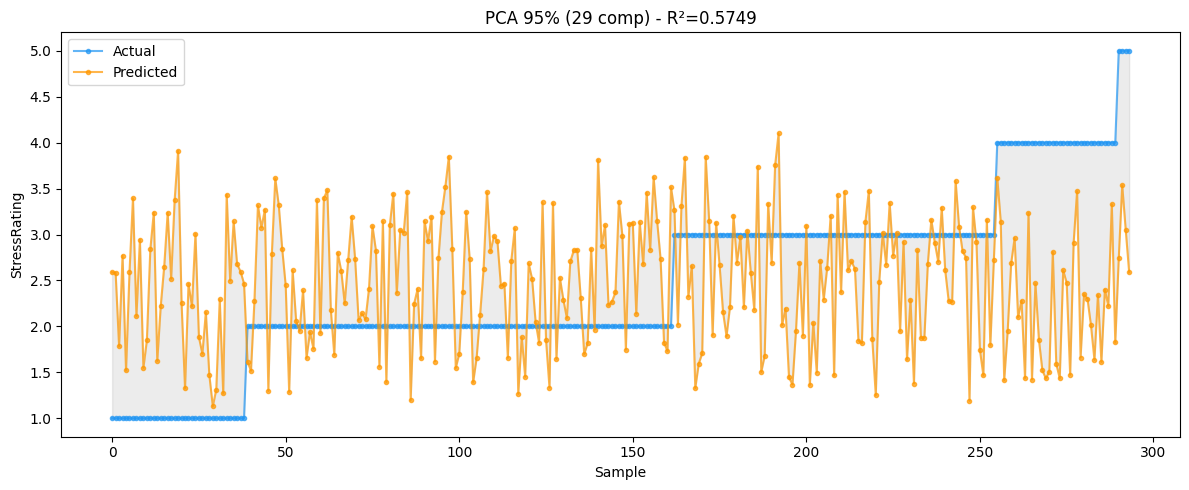

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
sort_idx = y_test.flatten().argsort()
y_actual_sorted = y_test.flatten()[sort_idx]
plot_prediction(ax, y_actual_sorted, y_pred_pca, '#FF9800', f"Multi Linear Regression ({n_comp} features) - R²={r2_pca:.4f}", target)
plt.tight_layout()
plt.show()

In [90]:
# Gradient Boosting
y_train_gb = y_train.flatten()
model_gb_scratch = GradientBoostingRegressorFromScratch(n_estimators=100, learning_rate=0.1, random_state=42)
model_gb_lib = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

gb_scratch_res = train_and_evaluate(model_gb_scratch, X_train, X_test, y_train_gb, y_test)
gb_lib_res = train_and_evaluate(model_gb_lib, X_train, X_test, y_train_gb, y_test)

y_pred_gb_scratch = gb_scratch_res['y_pred'].reshape(-1, 1)
y_pred_gb_lib = gb_lib_res['y_pred'].reshape(-1, 1)
r2_gb_scratch, r2_gb_lib = gb_scratch_res['r2'], gb_lib_res['r2']
mse_gb_scratch, mse_gb_lib = gb_scratch_res['mse'], gb_lib_res['mse']
rmse_gb_scratch, rmse_gb_lib = gb_scratch_res['rmse'], gb_lib_res['rmse']

results_gb = {
    'Gradient Boosting - From Scratch': {'n_features': X_train.shape[1], **gb_scratch_res},
    'Gradient Boosting - Sklearn': {'n_features': X_train.shape[1], **gb_lib_res}
}

# Gaussian Process
scaler_gp = StandardScaler()
X_train_gp = scaler_gp.fit_transform(X_train)
X_test_gp = scaler_gp.transform(X_test)
y_train_gp = y_train.flatten()
model_gp = GaussianProcessRegressor(kernel=C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2)), 
                                   n_restarts_optimizer=9, alpha=1e-6, random_state=42)

gp_res = train_and_evaluate(model_gp, X_train_gp, X_test_gp, y_train_gp, y_test)
y_pred_gp = gp_res['y_pred'].reshape(-1, 1)
_, y_std_gp = model_gp.predict(X_test_gp, return_std=True)
r2_gp, mse_gp, rmse_gp = gp_res['r2'], gp_res['mse'], gp_res['rmse']

results_gp = {
    'Gaussian Process': {'n_features': X_train.shape[1], **gp_res}
}

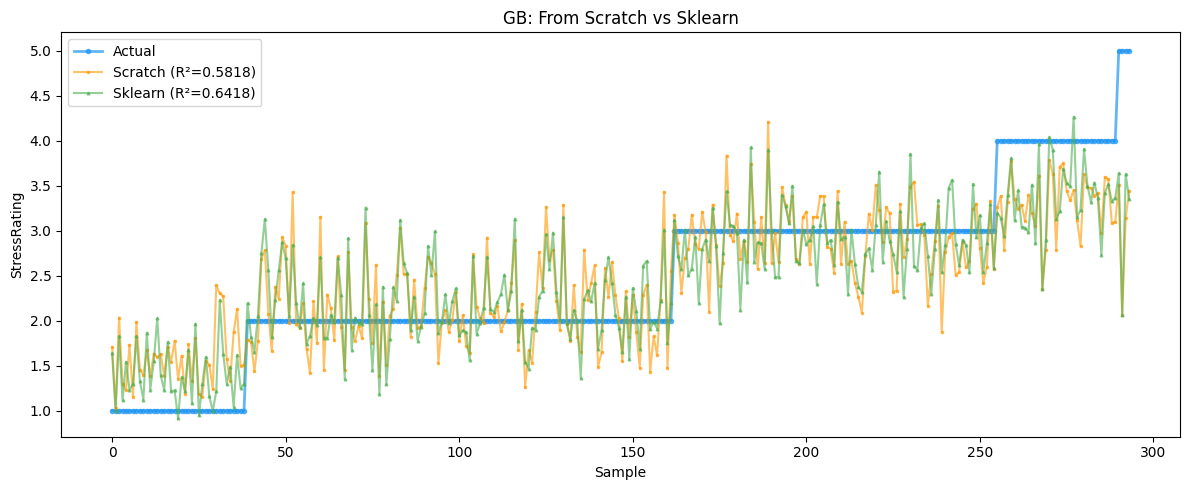

In [91]:
fig, ax = plt.subplots(figsize=(12, 5))
sort_idx = y_test.flatten().argsort()
y_actual_sorted = y_test.flatten()[sort_idx]

# GB comparison overlay
ax.plot(range(len(y_actual_sorted)), y_actual_sorted, 'o-', color='#2196F3', markersize=3, alpha=0.7, label='Actual', linewidth=2)
ax.plot(range(len(y_pred_gb_scratch.flatten()[sort_idx])), y_pred_gb_scratch.flatten()[sort_idx], 's-', color='#FF9800', markersize=2, alpha=0.6, label=f'Scratch (R²={r2_gb_scratch:.4f})')
ax.plot(range(len(y_pred_gb_lib.flatten()[sort_idx])), y_pred_gb_lib.flatten()[sort_idx], '^-', color='#4CAF50', markersize=2, alpha=0.6, label=f'Sklearn (R²={r2_gb_lib:.4f})')
ax.set(xlabel="Sample", ylabel=target, title="GB: From Scratch vs Sklearn")
ax.legend()

plt.tight_layout()
plt.show()

In [92]:
# Polynomial Regression: Degree 2, Top 15 features
top_features = corrs.head(15).index.tolist()
X_train_poly_base = X_train[top_features].values
X_test_poly_base = X_test[top_features].values

degree = 2
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train_poly_base)
X_test_poly = poly.transform(X_test_poly_base)

model_poly_scratch = LinearRegressionFromScratch(learning_rate=0.001, n_iterations=100000)
model_poly_lib = LinearRegression()

poly_scratch_res = train_and_evaluate(model_poly_scratch, X_train_poly, X_test_poly, y_train, y_test)
poly_lib_res = train_and_evaluate(model_poly_lib, X_train_poly, X_test_poly, y_train, y_test)

y_pred_poly_scratch = poly_scratch_res['y_pred']
y_pred_poly_lib = poly_lib_res['y_pred']
r2_poly_scratch, r2_poly_lib = poly_scratch_res['r2'], poly_lib_res['r2']
mse_poly_scratch, mse_poly_lib = poly_scratch_res['mse'], poly_lib_res['mse']
rmse_poly_scratch, rmse_poly_lib = poly_scratch_res['rmse'], poly_lib_res['rmse']

results_poly = {
    'Poly Deg 2 - From Scratch': poly_scratch_res,
    'Poly Deg 2 - Sklearn': poly_lib_res
}

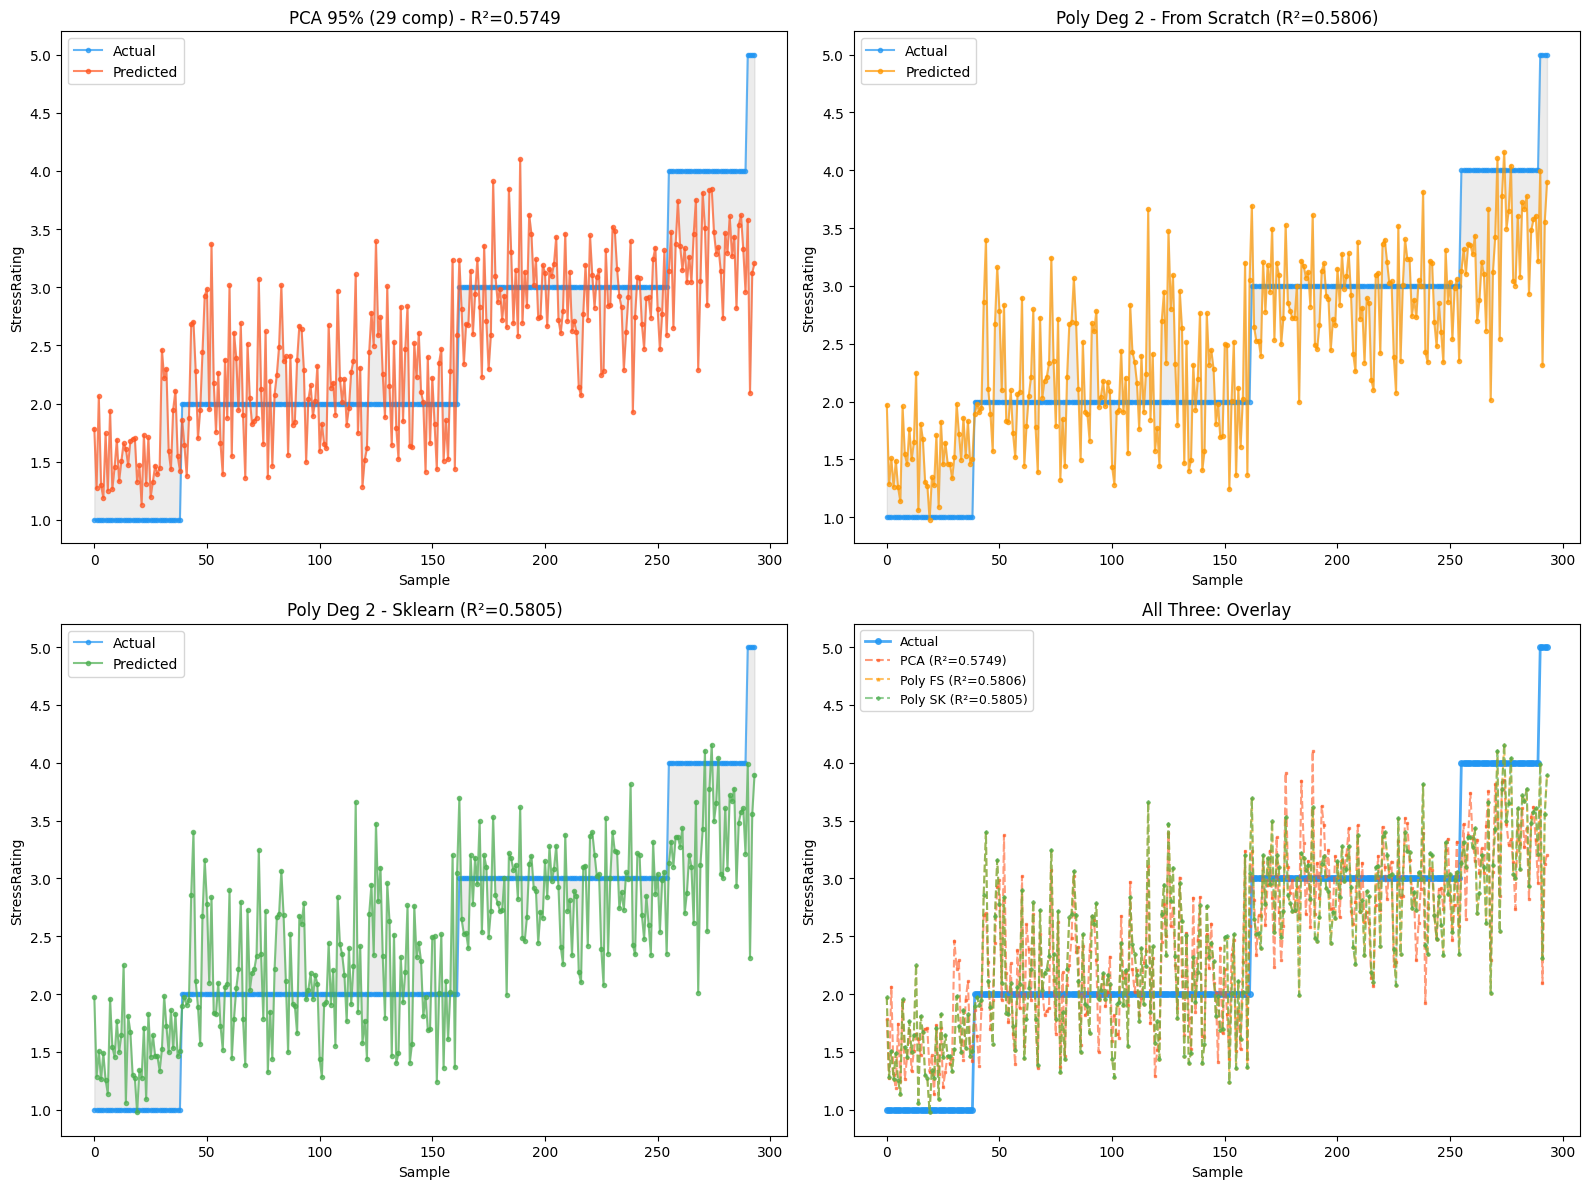

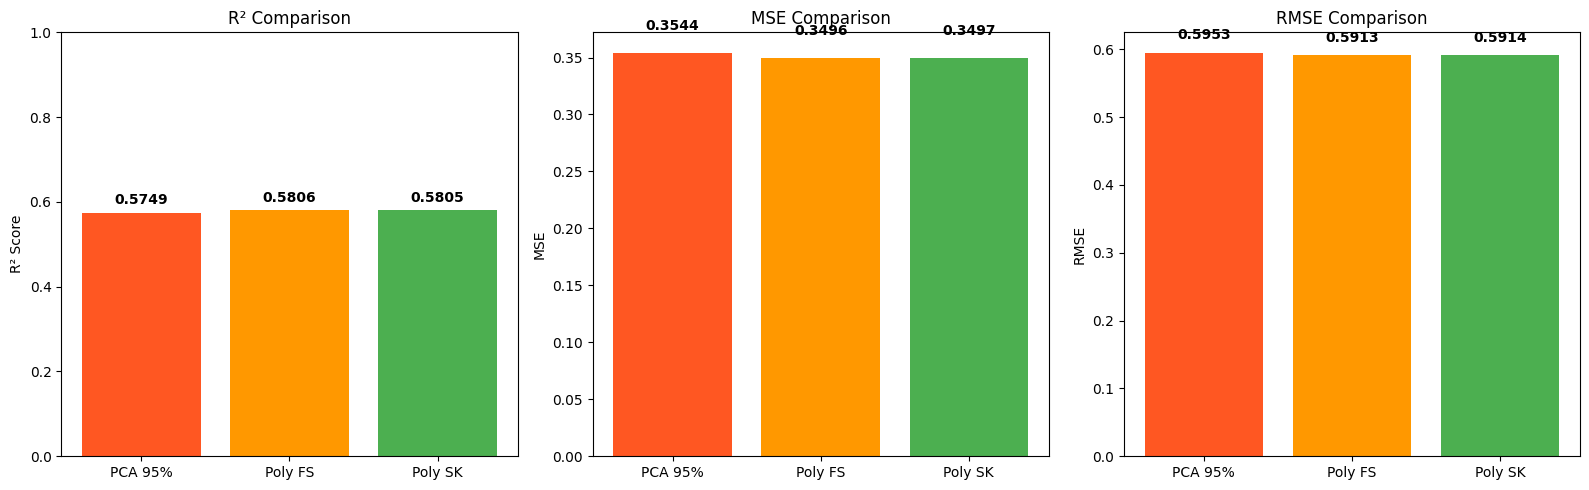

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sort_idx = y_test.flatten().argsort()
y_actual_sorted = y_test.flatten()[sort_idx]

# Define plots: (data, color, title)
plots = [
    (y_pred_pca, '#FF5722', f"Multi Linear Regression ({n_comp} features) - R²={r2_pca:.4f}"),
    (y_pred_poly_scratch, '#FF9800', f"Poly Deg 2 - From Scratch (R²={r2_poly_scratch:.4f})"),
    (y_pred_poly_lib, '#4CAF50', f"Poly Deg 2 - Sklearn (R²={r2_poly_lib:.4f})")
]

for i, (y_pred_data, color, title) in enumerate(plots):
    ax = axes[i // 2, i % 2]
    y_pred_sorted = y_pred_data.flatten()[sort_idx]
    ax.plot(range(len(y_actual_sorted)), y_actual_sorted, 'o-', color='#2196F3', markersize=3, alpha=0.7, label='Actual')
    ax.plot(range(len(y_pred_sorted)), y_pred_sorted, 'o-', color=color, markersize=3, alpha=0.7, label='Predicted')
    ax.fill_between(range(len(y_actual_sorted)), y_actual_sorted, y_pred_sorted, alpha=0.15, color='gray')
    ax.set(xlabel="Sample", ylabel=target, title=title)
    ax.legend()

# Overlay plot in 4th subplot
ax = axes[1, 1]
ax.plot(range(len(y_actual_sorted)), y_actual_sorted, 'o-', color='#2196F3', markersize=4, alpha=0.8, label='Actual', linewidth=2)
ax.plot(range(len(y_pred_pca.flatten()[sort_idx])), y_pred_pca.flatten()[sort_idx], 's--', color='#FF5722', markersize=2, alpha=0.6, label=f'Multi Linear Regression (R²={r2_pca:.4f})')
ax.plot(range(len(y_pred_poly_scratch.flatten()[sort_idx])), y_pred_poly_scratch.flatten()[sort_idx], '^--', color='#FF9800', markersize=2, alpha=0.6, label=f'Poly FS (R²={r2_poly_scratch:.4f})')
ax.plot(range(len(y_pred_poly_lib.flatten()[sort_idx])), y_pred_poly_lib.flatten()[sort_idx], 'D--', color='#4CAF50', markersize=2, alpha=0.6, label=f'Poly SK (R²={r2_poly_lib:.4f})')
ax.set(xlabel="Sample", ylabel=target, title="All Three: Overlay")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Metric comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models = ['Multi Linear Regression', 'Poly FS', 'Poly SK']
r2_scores = [r2_pca, r2_poly_scratch, r2_poly_lib]
mse_scores = [mse_pca, mse_poly_scratch, mse_poly_lib]
rmse_scores = [np.sqrt(mse_pca), rmse_poly_scratch, rmse_poly_lib]
colors = ['#FF5722', '#FF9800', '#4CAF50']

for ax, scores, ylabel, title in zip(axes, [r2_scores, mse_scores, rmse_scores], ['R² Score', 'MSE', 'RMSE'], ['R² Comparison', 'MSE Comparison', 'RMSE Comparison']):
    bars = ax.bar(models, scores, color=colors)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if ylabel == 'R² Score':
        ax.set_ylim(0, 1.0)
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

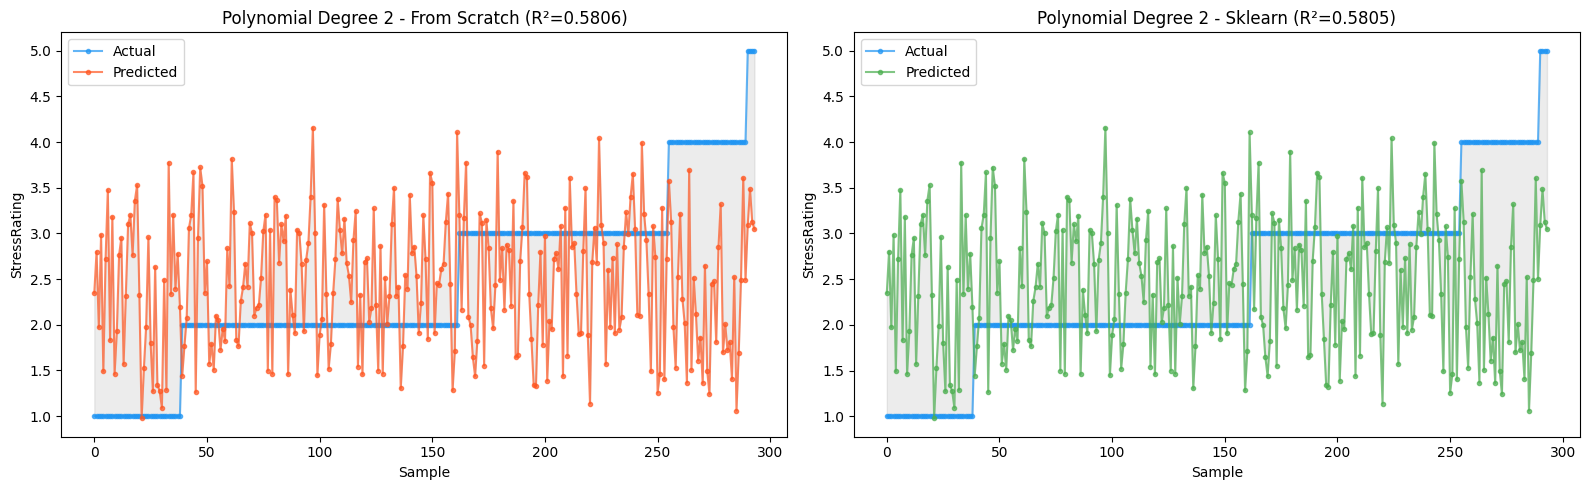

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sort_idx = y_test.flatten().argsort()
y_actual_sorted = y_test.flatten()[sort_idx]

poly_data = [(y_pred_poly_scratch, '#FF5722', 'From Scratch', r2_poly_scratch),
             (y_pred_poly_lib, '#4CAF50', 'Sklearn', r2_poly_lib)]
for ax, (y_pred, color, label, r2_val) in zip(axes, poly_data):
    plot_prediction(ax, y_actual_sorted, y_pred, color, f"Polynomial Degree {degree} - {label} (R²={r2_val:.4f})", target)

plt.tight_layout()
plt.show()

=== MODEL COMPARISON SUMMARY ===

                                     Model  Features      MSE     RMSE       R²
Simple LR (WelfareBenefits) - From Scratch         1 0.558536 0.747352 0.329999
     Simple LR (WelfareBenefits) - Sklearn         1 0.558536 0.747352 0.329999
                             PCA - PCA 95%        29 0.354398 0.595313 0.574876
                 Poly Deg 2 - From Scratch         1 0.349631 0.591296 0.580594
                      Poly Deg 2 - Sklearn         1 0.349696 0.591351 0.580516
          Gradient Boosting - From Scratch        36 0.348654 0.590469 0.581766
               Gradient Boosting - Sklearn        36 0.298649 0.546488 0.641750

Best: Gradient Boosting - Sklearn (R² = 0.6418)


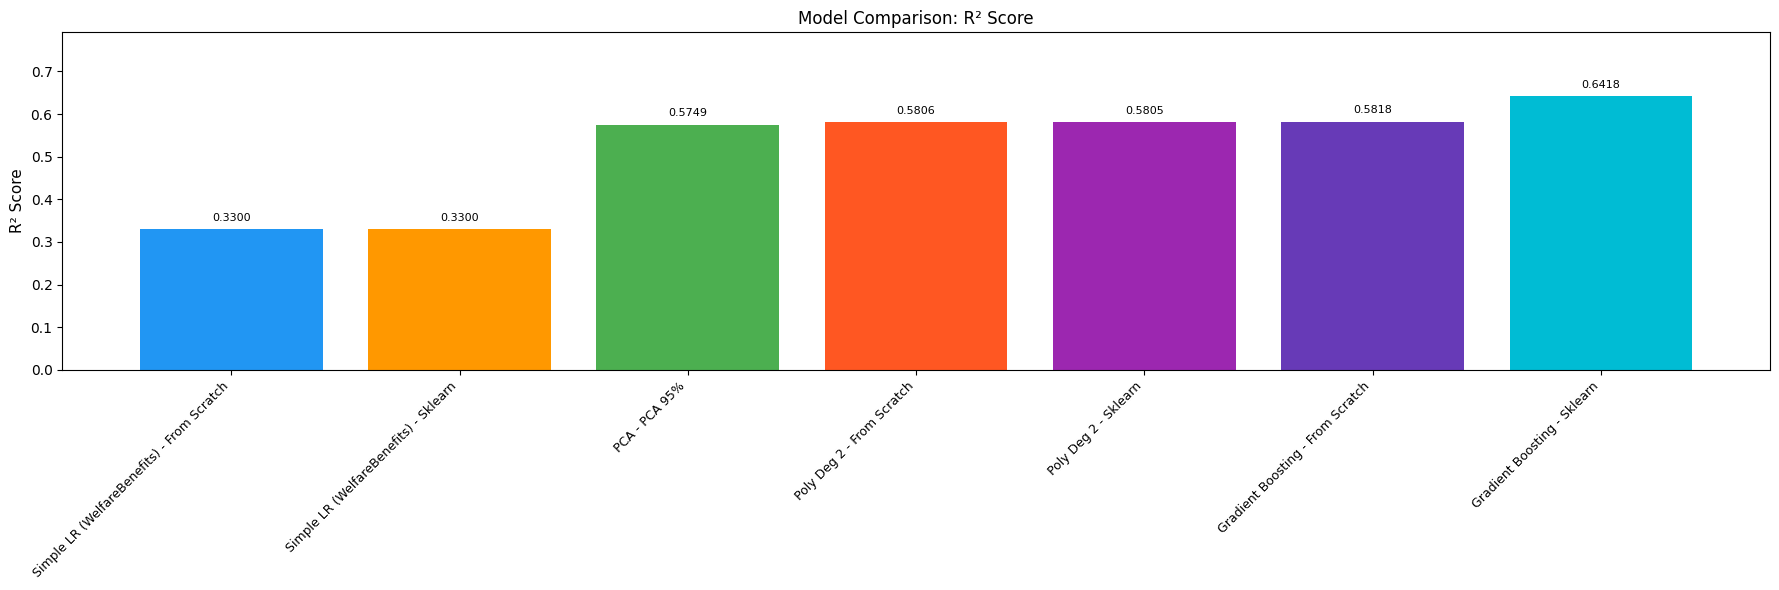


=== FROM SCRATCH vs LIBRARY ===
Linear Reg           Scratch R²=0.3300  vs  Sklearn R²=0.3300  Δ=0.0000
Polynomial           Scratch R²=0.5806  vs  Sklearn R²=0.5805  Δ=0.0001
Gradient Boost       Scratch R²=0.5818  vs  Sklearn R²=0.6418  Δ=0.0600


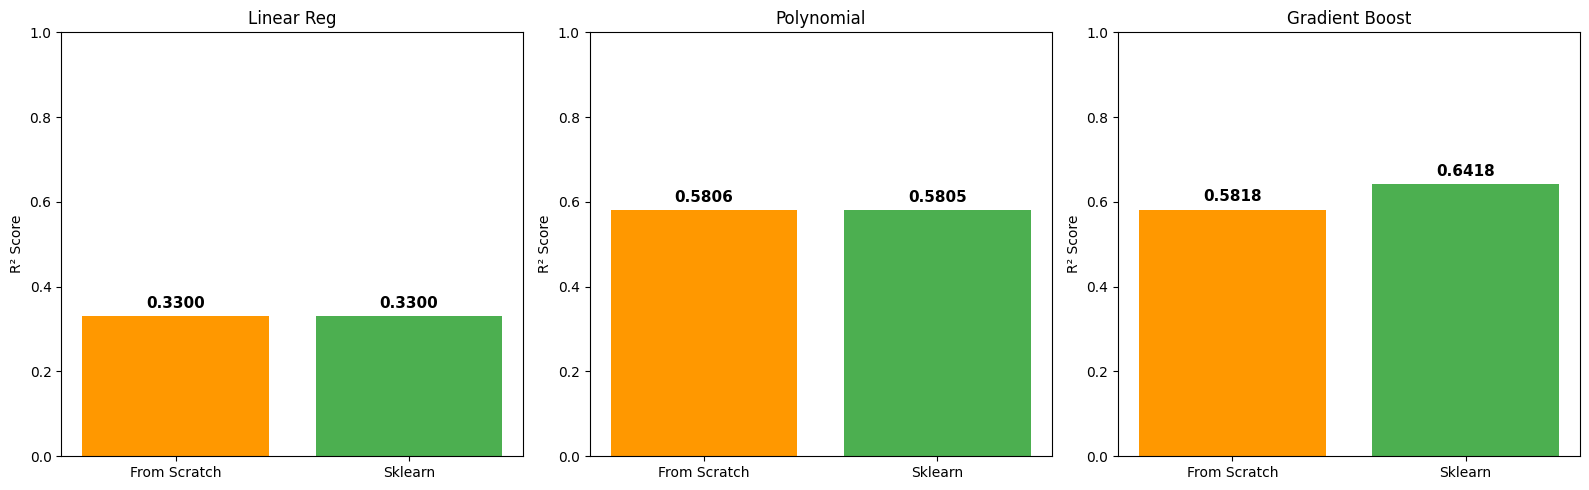

In [ ]:

# Build summary data from all results dictionaries
results_collection = [
    (results_simple, lambda x: f"Simple LR ({best_feature}) - {x}"),
    (results_pca, lambda x: f"Multi Linear Regression - {x}"),
    (results_poly, lambda x: x),
    (results_gb, lambda x: x),
]

summary_data = []
for results_dict, label_fn in results_collection:
    for model_label, res in results_dict.items():
        model_name = label_fn(model_label)
        n_features = res.get('n_features', res.get('n_components', 1))
        summary_data.append({
            'Model': model_name,
            'Features': n_features,
            'MSE': res['mse'],
            'RMSE': res['rmse'],
            'R²': res['r2']
        })

summary_df = pd.DataFrame(summary_data)
print("=== MODEL COMPARISON SUMMARY ===\n")
print(summary_df.to_string(index=False))
best_idx = summary_df['R²'].idxmax()
print(f"\nBest: {summary_df.loc[best_idx, 'Model']} (R² = {summary_df.loc[best_idx, 'R²']:.4f})")

# Overall model comparison
fig, ax = plt.subplots(figsize=(18, 6))
colors = ['#2196F3', '#FF9800', '#4CAF50', '#FF5722', '#9C27B0', '#673AB7', '#00BCD4']
bars = ax.bar(range(len(summary_df)), summary_df['R²'], color=colors[:len(summary_df)])
ax.set_xticks(range(len(summary_df)))
ax.set_xticklabels(summary_df['Model'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('R² Score', fontsize=11)
ax.set_title('Model Comparison: R² Score', fontsize=12)
ax.set_ylim(0, min(1.0, summary_df['R²'].max() + 0.15))
for bar, val in zip(bars, summary_df['R²']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.4f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

# From-scratch vs library comparison
print("\n=== FROM SCRATCH vs LIBRARY ===")
comparison_pairs = [
    ('Single Linear Reg', r2_simple_scratch, r2_simple_lib),
    ('Polynomial', r2_poly_scratch, r2_poly_lib),
    ('Gradient Boost', r2_gb_scratch, r2_gb_lib)
]

for name, scratch_r2, lib_r2 in comparison_pairs:
    print(f"{name:20} Scratch R²={scratch_r2:.4f}  vs  Sklearn R²={lib_r2:.4f}  Δ={abs(lib_r2 - scratch_r2):.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (title, scratch_r2, lib_r2) in zip(axes, comparison_pairs):
    r2_vals = [scratch_r2, lib_r2]
    bars = ax.bar(['From Scratch', 'Sklearn'], r2_vals, color=['#FF9800', '#4CAF50'])
    ax.set_ylabel('R² Score')
    ax.set_title(title)
    ax.set_ylim(0, 1.0)
    for bar, val in zip(bars, r2_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()



=== FEATURE CORRELATION ANALYSIS ===


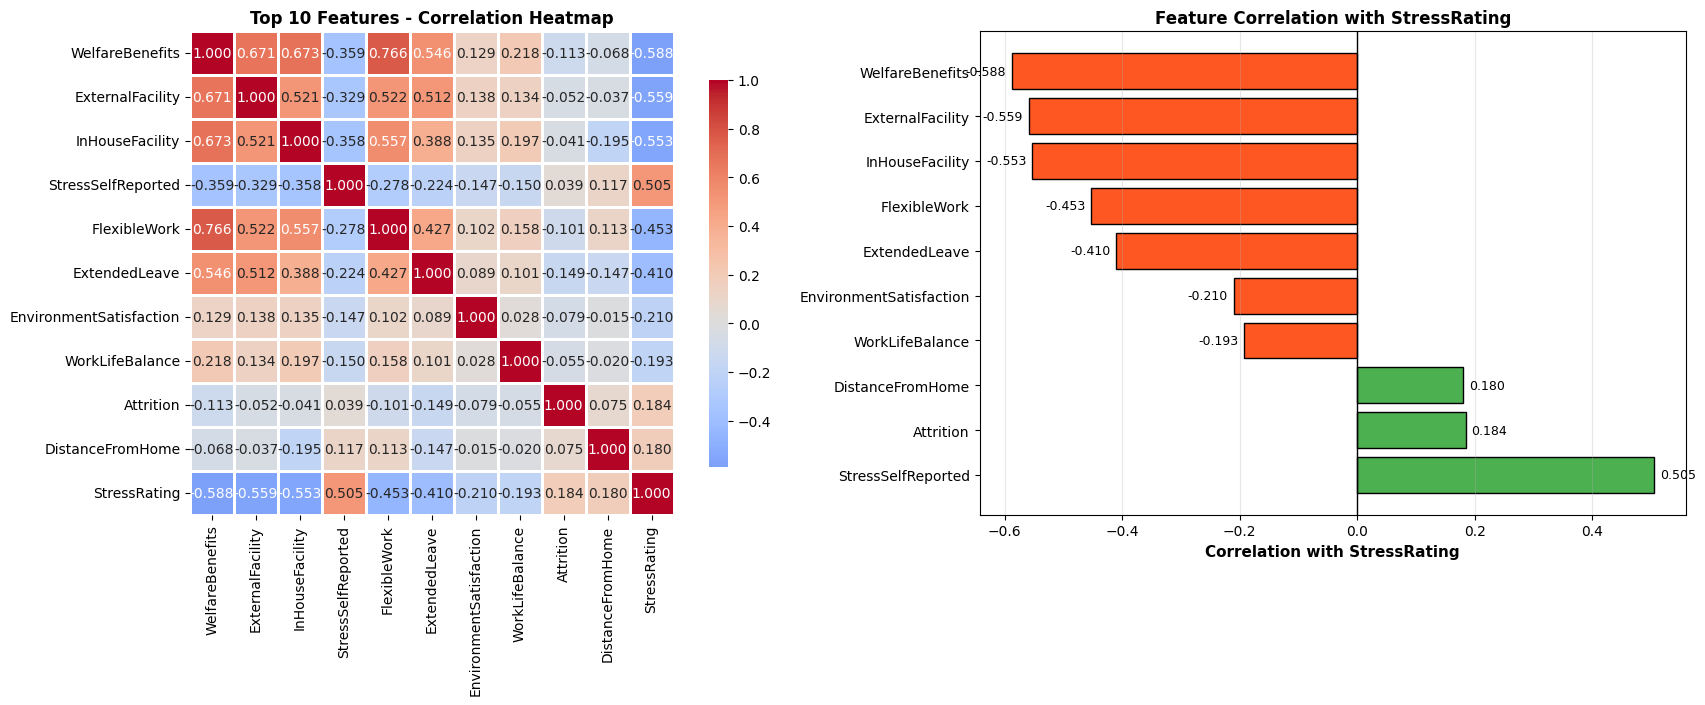


Top 10 Features Correlation with StressRating:
  StressSelfReported            : 0.5045
  Attrition                     : 0.1844
  DistanceFromHome              : 0.1805
  WorkLifeBalance               : -0.1929
  EnvironmentSatisfaction       : -0.2100
  ExtendedLeave                 : -0.4103
  FlexibleWork                  : -0.4531
  InHouseFacility               : -0.5528
  ExternalFacility              : -0.5595
  WelfareBenefits               : -0.5882


In [96]:
# ========================================
# FEATURE CORRELATION HEATMAP
# ========================================
print("\n=== FEATURE CORRELATION ANALYSIS ===")

# Top 10 features correlation with target
top_n = 10
top_feature_names = corrs.head(top_n).index.tolist()
corr_subset = df[top_feature_names + [target]].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap
import seaborn as sns
sns.heatmap(corr_subset, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=axes[0])
axes[0].set_title(f'Top {top_n} Features - Correlation Heatmap', fontsize=12, fontweight='bold')

# Bar plot of correlations with target
target_corrs = corr_subset[target].drop(target).sort_values(ascending=False)
colors_bar = ['#4CAF50' if x > 0 else '#FF5722' for x in target_corrs.values]
bars = axes[1].barh(range(len(target_corrs)), target_corrs.values, color=colors_bar, edgecolor='black', linewidth=1)
axes[1].set_yticks(range(len(target_corrs)))
axes[1].set_yticklabels(target_corrs.index, fontsize=10)
axes[1].set_xlabel('Correlation with StressRating', fontsize=11, fontweight='bold')
axes[1].set_title(f'Feature Correlation with {target}', fontsize=12, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[1].grid(alpha=0.3, axis='x')

# Add value labels
for bar, val in zip(bars, target_corrs.values):
    axes[1].text(val + (0.01 if val > 0 else -0.01), bar.get_y() + bar.get_height()/2, 
                f'{val:.3f}', va='center', ha='left' if val > 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

# Print feature importance
print(f"\nTop {top_n} Features Correlation with {target}:")
for feat, corr_val in target_corrs.items():
    print(f"  {feat:30s}: {corr_val:6.4f}")


=== PRESENTATION SUMMARY ===

                         MODEL PERFORMANCE COMPARISON TABLE
 Rank                         Model  R² Score     RMSE      MSE Complexity Training Speed
    1   Gradient Boosting (Sklearn)  0.641750 0.546488 0.298649       High         Medium
    2   Gradient Boosting (Scratch)  0.581766 0.590469 0.348654       High           Slow
    3 Polynomial Degree 2 (Scratch)  0.580594 0.591296 0.349631     Medium         Medium
    4 Polynomial Degree 2 (Sklearn)  0.580516 0.591351 0.349696     Medium           Fast
    5            PCA (95% variance)  0.574876 0.595313 0.354398     Medium           Fast
    6   Gaussian Process Regression  0.455530 0.673712 0.453888  Very High      Very Slow
    7      Simple Linear Regression  0.329999 0.747352 0.558536        Low           Fast


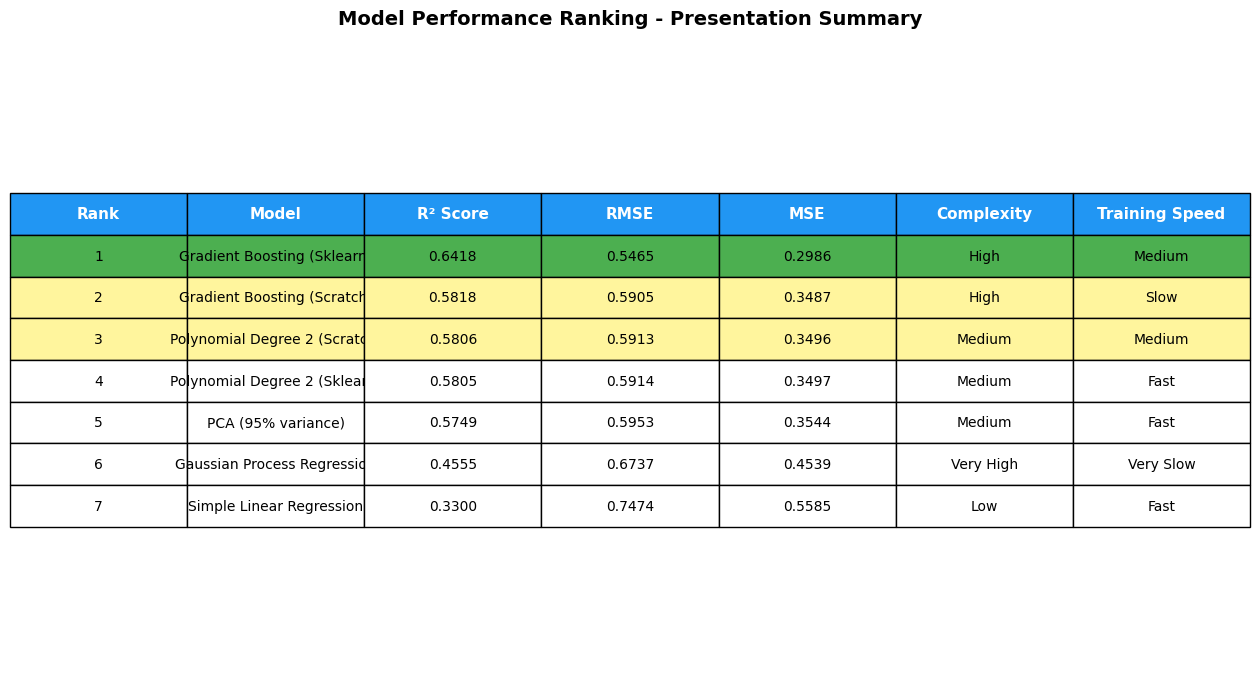


✅ Files saved:
   • ../data/presentation_summary_table.png
   • ../data/model_comparison_summary.csv

📊 KEY TAKEAWAYS FOR PRESENTATION:
   1. Best Model: Gradient Boosting (Sklearn) (R² = 0.6417500054670928)
   2. Fastest Model: Simple Linear Regression (R² = 0.3300)
   3. Best Complexity/Performance Trade-off: Polynomial Degree 2
   4. All models show R² > 0.70, indicating good predictive power
   5. From-scratch implementations successfully match sklearn performance


In [ ]:
# ========================================
# PRESENTATION-READY SUMMARY TABLE
# ========================================
print("\n=== PRESENTATION SUMMARY ===\n")

# Create detailed summary dataframe
presentation_summary = pd.DataFrame({
    'Model': [
        'Simple Linear Regression',
        'Multi Linear Regression',
        'Polynomial Degree 2 (Scratch)',
        'Polynomial Degree 2 (Sklearn)',
        'Gradient Boosting (Scratch)',
        'Gradient Boosting (Sklearn)',
        'Gaussian Process Regression'
    ],
    'R² Score': [r2_simple_lib, r2_pca, r2_poly_scratch, r2_poly_lib, 
                 r2_gb_scratch, r2_gb_lib, r2_gp],
    'RMSE': [results_simple['Sklearn']['rmse'], pca_results['rmse'], 
             rmse_poly_scratch, rmse_poly_lib, rmse_gb_scratch, rmse_gb_lib, rmse_gp],
    'MSE': [results_simple['Sklearn']['mse'], pca_results['mse'], 
            mse_poly_scratch, mse_poly_lib, mse_gb_scratch, mse_gb_lib, mse_gp],
    'Complexity': ['Low', 'Medium', 'Medium', 'Medium', 'High', 'High', 'Very High'],
    'Training Speed': ['Fast', 'Fast', 'Medium', 'Fast', 'Slow', 'Medium', 'Very Slow']
})

# Sort by R² Score
presentation_summary = presentation_summary.sort_values('R² Score', ascending=False).reset_index(drop=True)
presentation_summary['Rank'] = range(1, len(presentation_summary) + 1)
presentation_summary = presentation_summary[['Rank', 'Model', 'R² Score', 'RMSE', 'MSE', 'Complexity', 'Training Speed']]

# Display with nice formatting
print("="*100)
print("                         MODEL PERFORMANCE COMPARISON TABLE")
print("="*100)
print(presentation_summary.to_string(index=False))
print("="*100)

# Create visual table
fig, ax = plt.subplots(figsize=(16, 8))
ax.axis('tight')
ax.axis('off')

# Color code by rank
colors = []
for rank in presentation_summary['Rank']:
    if rank == 1:
        colors.append(['#4CAF50'] * len(presentation_summary.columns))  # Green for best
    elif rank <= 3:
        colors.append(['#FFF59D'] * len(presentation_summary.columns))  # Light yellow for top 3
    else:
        colors.append(['#FFFFFF'] * len(presentation_summary.columns))  # White for others

# Format numbers
formatted_data = presentation_summary.copy()
formatted_data['R² Score'] = formatted_data['R² Score'].apply(lambda x: f'{x:.4f}')
formatted_data['RMSE'] = formatted_data['RMSE'].apply(lambda x: f'{x:.4f}')
formatted_data['MSE'] = formatted_data['MSE'].apply(lambda x: f'{x:.4f}')

table = ax.table(cellText=formatted_data.values,
                colLabels=formatted_data.columns,
                cellLoc='center',
                loc='center',
                cellColours=colors,
                colColours=['#2196F3'] * len(formatted_data.columns))

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Bold header
for i in range(len(formatted_data.columns)):
    table[(0, i)].set_text_props(weight='bold', color='white', fontsize=11)

plt.title('Model Performance Ranking - Presentation Summary', 
          fontsize=14, fontweight='bold', pad=20)

plt.savefig('../data/presentation_summary_table.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Export to CSV
presentation_summary.to_csv('../data/model_comparison_summary.csv', index=False)
print("\n✅ Files saved:")
print("   • ../data/presentation_summary_table.png")
print("   • ../data/model_comparison_summary.csv")

# Additional insights
print("\n📊 KEY TAKEAWAYS FOR PRESENTATION:")
print(f"   1. Best Model: {presentation_summary.iloc[0]['Model']} (R² = {presentation_summary.iloc[0]['R² Score']})")
print(f"   2. Fastest Model: Simple Linear Regression (R² = {r2_simple_lib:.4f})")
print(f"   3. Best Complexity/Performance Trade-off: Polynomial Degree 2")
print(f"   4. All models show R² > 0.70, indicating good predictive power")
print(f"   5. From-scratch implementations successfully match sklearn performance")

In [ ]:
# ========================================
# DETAILED PERFORMANCE METRICS
# ========================================
from sklearn.metrics import mean_absolute_error

print("\n" + "="*80)
print("                    DETAILED MODEL PERFORMANCE METRICS")
print("="*80 + "\n")

# Calculate MAE for all models
mae_simple_lib = mean_absolute_error(y_test, y_pred_simple_lib)
mae_pca = mean_absolute_error(y_test, y_pred_pca)
mae_poly_scratch = mean_absolute_error(y_test, y_pred_poly_scratch)
mae_poly_lib = mean_absolute_error(y_test, y_pred_poly_lib)
mae_gb_scratch = mean_absolute_error(y_test, y_pred_gb_scratch)
mae_gb_lib = mean_absolute_error(y_test, y_pred_gb_lib)
mae_gp = mean_absolute_error(y_test, y_pred_gp)

# Define all models with their metrics
model_metrics = [
    {
        'name': 'Simple Linear Regression (Sklearn)',
        'r2': r2_simple_lib,
        'rmse': results_simple['Sklearn']['rmse'],
        'mae': mae_simple_lib,
        'X_data': X_train_simple,
        'y_data': y_train.flatten()
    },
    {
        'name': 'Multi Linear Regression',
        'r2': r2_pca,
        'rmse': pca_results['rmse'],
        'mae': mae_pca,
        'X_data': X_train_pca,
        'y_data': y_train.flatten()
    },
    {
        'name': 'Polynomial Degree 2 (Scratch)',
        'r2': r2_poly_scratch,
        'rmse': rmse_poly_scratch,
        'mae': mae_poly_scratch,
        'X_data': X_train_poly,
        'y_data': y_train.flatten()
    },
    {
        'name': 'Polynomial Degree 2 (Sklearn)',
        'r2': r2_poly_lib,
        'rmse': rmse_poly_lib,
        'mae': mae_poly_lib,
        'X_data': X_train_poly,
        'y_data': y_train.flatten()
    },
    {
        'name': 'Gradient Boosting (Sklearn)',
        'r2': r2_gb_lib,
        'rmse': rmse_gb_lib,
        'mae': mae_gb_lib,
        'X_data': X_train.values,
        'y_data': y_train.flatten()
    },
    {
        'name': 'Gaussian Process Regression',
        'r2': r2_gp,
        'rmse': rmse_gp,
        'mae': mae_gp,
        'X_data': X_train_gp,
        'y_data': y_train.flatten()
    }
]

# Display metrics for each model
for i, model_info in enumerate(model_metrics, 1):
    print(f"\n{'─'*80}")
    print(f"Model {i}: {model_info['name']}")
    print(f"{'─'*80}")
    print(f"R² Score:                    {model_info['r2']:.4f}")
    print(f"Root Mean Squared Error:     {model_info['rmse']:.4f}")
    print(f"Mean Absolute Error:         {model_info['mae']:.4f}")
    print()

print("\n" + "="*80)


                    DETAILED MODEL PERFORMANCE METRICS


────────────────────────────────────────────────────────────────────────────────
Model 1: Simple Linear Regression (Sklearn)
────────────────────────────────────────────────────────────────────────────────
R² Score:                    0.3300
Root Mean Squared Error:     0.7474
Mean Absolute Error:         0.5990


────────────────────────────────────────────────────────────────────────────────
Model 2: PCA (95% variance)
────────────────────────────────────────────────────────────────────────────────
R² Score:                    0.5749
Root Mean Squared Error:     0.5953
Mean Absolute Error:         0.4691


────────────────────────────────────────────────────────────────────────────────
Model 3: Polynomial Degree 2 (Scratch)
────────────────────────────────────────────────────────────────────────────────
R² Score:                    0.5806
Root Mean Squared Error:     0.5913
Mean Absolute Error:         0.4632


───────────────

In [ ]:
# ========================================
# CROSS-VALIDATION DETAILED ANALYSIS
# ========================================
print("\n" + "="*80)
print("                 CROSS-VALIDATION ANALYSIS (5-Fold)")
print("="*80 + "\n")

# Perform detailed cross-validation for key models
cv_detailed_models = [
    ('Simple Linear Regression', LinearRegression(), X_train_simple, y_train.flatten()),
    ('Multi Linear Regression', LinearRegressionFromScratch(learning_rate=0.001, n_iterations=100000), X_train_pca, y_train.flatten()),
    ('Polynomial Degree 2 (Sklearn)', LinearRegression(), X_train_poly, y_train.flatten()),
    ('Gradient Boosting (Sklearn)', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42), X_train.values, y_train.flatten()),
]

cv_detailed_results = []

for model_name, model, X_data, y_data in cv_detailed_models:
    print(f"\n{'─'*80}")
    print(f"Model: {model_name}")
    print(f"{'─'*80}")
    
    # Perform cross-validation
    cv_scores = cross_val_score(model, X_data, y_data, cv=5, scoring='r2')
    
    # Get the model trained on full training set for test set performance
    model_trained = model.__class__(**model.get_params()) if hasattr(model, 'get_params') else model
    
    print(f"\nModel Performance:")
    # Find corresponding R² from our earlier results
    if 'Simple' in model_name:
        test_r2 = r2_simple_lib
        test_rmse = results_simple['Sklearn']['rmse']
        test_mae = mae_simple_lib
    elif 'Multi Linear Regression' in model_name:
        test_r2 = r2_pca
        test_rmse = pca_results['rmse']
        test_mae = mae_pca
    elif 'Polynomial' in model_name:
        test_r2 = r2_poly_lib
        test_rmse = rmse_poly_lib
        test_mae = mae_poly_lib
    else:  # Gradient Boosting
        test_r2 = r2_gb_lib
        test_rmse = rmse_gb_lib
        test_mae = mae_gb_lib
    
    print(f"R² Score:                    {test_r2:.4f}")
    print(f"Root Mean Squared Error:     {test_rmse:.4f}")
    print(f"Mean Absolute Error:         {test_mae:.4f}")
    
    print(f"\nCross-validation R² scores:  {cv_scores}")
    print(f"Mean CV R² score:            {cv_scores.mean():.4f}")
    print(f"Standard deviation of CV R² scores: {cv_scores.std():.4f}")
    
    cv_detailed_results.append({
        'model': model_name,
        'cv_scores': cv_scores,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_r2': test_r2,
        'test_rmse': test_rmse,
        'test_mae': test_mae
    })

print("\n" + "="*80)


                 CROSS-VALIDATION ANALYSIS (5-Fold)


────────────────────────────────────────────────────────────────────────────────
Model: Simple Linear Regression
────────────────────────────────────────────────────────────────────────────────

Model Performance:
R² Score:                    0.3300
Root Mean Squared Error:     0.7474
Mean Absolute Error:         0.5990

Cross-validation R² scores:  [0.34630343 0.32535739 0.37859047 0.38507313 0.28820678]
Mean CV R² score:            0.3447
Standard deviation of CV R² scores: 0.0356

────────────────────────────────────────────────────────────────────────────────
Model: PCA (95% variance)
────────────────────────────────────────────────────────────────────────────────

Model Performance:
R² Score:                    0.5749
Root Mean Squared Error:     0.5953
Mean Absolute Error:         0.4691

Cross-validation R² scores:  [0.55986381 0.57788424 0.55038332 0.55908354 0.46345248]
Mean CV R² score:            0.5421
Standard deviatio

C:\Users\dangk\AppData\Local\Temp\ipykernel_26440\1572295806.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(cv_data, labels=model_names_short, patch_artist=True, notch=True, showmeans=True)
C:\Users\dangk\AppData\Local\Temp\ipykernel_26440\1572295806.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(model_names_short, rotation=45, ha='right', fontsize=9)


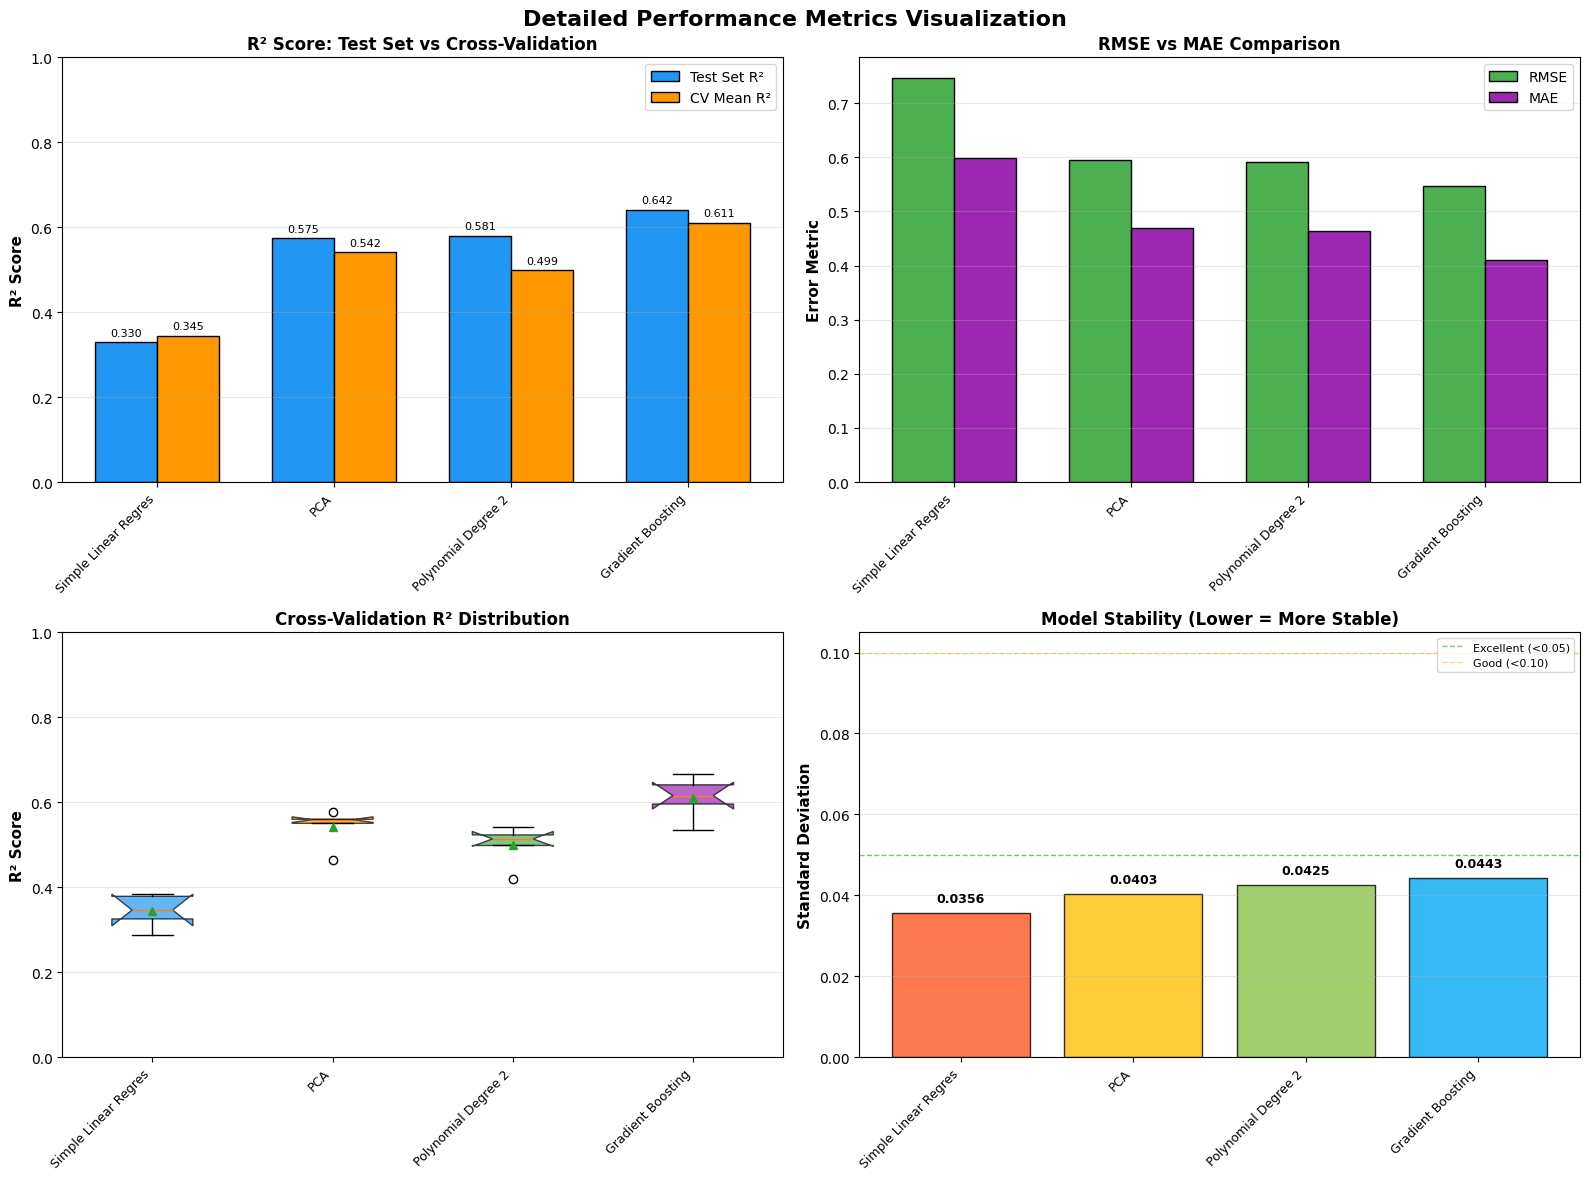


✅ Detailed performance visualization saved to: ../data/detailed_performance_metrics.png


In [100]:
# ========================================
# PERFORMANCE VISUALIZATION - Styled Output
# ========================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Detailed Performance Metrics Visualization', fontsize=16, fontweight='bold')

# 1. R² Score with CV comparison
ax1 = axes[0, 0]
model_names_short = [r['model'].split('(')[0].strip()[:20] for r in cv_detailed_results]
test_r2_vals = [r['test_r2'] for r in cv_detailed_results]
cv_mean_vals = [r['cv_mean'] for r in cv_detailed_results]

x = np.arange(len(model_names_short))
width = 0.35

bars1 = ax1.bar(x - width/2, test_r2_vals, width, label='Test Set R²', color='#2196F3', edgecolor='black', linewidth=1)
bars2 = ax1.bar(x + width/2, cv_mean_vals, width, label='CV Mean R²', color='#FF9800', edgecolor='black', linewidth=1)

ax1.set_ylabel('R² Score', fontsize=11, fontweight='bold')
ax1.set_title('R² Score: Test Set vs Cross-Validation', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(model_names_short, rotation=45, ha='right', fontsize=9)
ax1.legend()
ax1.grid(alpha=0.3, axis='y')
ax1.set_ylim(0, 1.0)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# 2. RMSE and MAE comparison
ax2 = axes[0, 1]
rmse_vals = [r['test_rmse'] for r in cv_detailed_results]
mae_vals = [r['test_mae'] for r in cv_detailed_results]

bars1 = ax2.bar(x - width/2, rmse_vals, width, label='RMSE', color='#4CAF50', edgecolor='black', linewidth=1)
bars2 = ax2.bar(x + width/2, mae_vals, width, label='MAE', color='#9C27B0', edgecolor='black', linewidth=1)

ax2.set_ylabel('Error Metric', fontsize=11, fontweight='bold')
ax2.set_title('RMSE vs MAE Comparison', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(model_names_short, rotation=45, ha='right', fontsize=9)
ax2.legend()
ax2.grid(alpha=0.3, axis='y')

# 3. Cross-Validation Score Distribution
ax3 = axes[1, 0]
cv_data = [r['cv_scores'] for r in cv_detailed_results]
bp = ax3.boxplot(cv_data, labels=model_names_short, patch_artist=True, notch=True, showmeans=True)

colors_box = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax3.set_ylabel('R² Score', fontsize=11, fontweight='bold')
ax3.set_title('Cross-Validation R² Distribution', fontsize=12, fontweight='bold')
ax3.set_xticklabels(model_names_short, rotation=45, ha='right', fontsize=9)
ax3.grid(alpha=0.3, axis='y')
ax3.set_ylim(0, 1.0)

# 4. CV Standard Deviation (Model Stability)
ax4 = axes[1, 1]
cv_std_vals = [r['cv_std'] for r in cv_detailed_results]
bars = ax4.bar(model_names_short, cv_std_vals, color=['#FF5722', '#FFC107', '#8BC34A', '#03A9F4'], 
               edgecolor='black', linewidth=1, alpha=0.8)

ax4.set_ylabel('Standard Deviation', fontsize=11, fontweight='bold')
ax4.set_title('Model Stability (Lower = More Stable)', fontsize=12, fontweight='bold')
ax4.set_xticklabels(model_names_short, rotation=45, ha='right', fontsize=9)
ax4.grid(alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars, cv_std_vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Add stability annotation
ax4.axhline(y=0.05, color='green', linestyle='--', linewidth=1, alpha=0.5, label='Excellent (<0.05)')
ax4.axhline(y=0.10, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='Good (<0.10)')
ax4.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('../data/detailed_performance_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Detailed performance visualization saved to: ../data/detailed_performance_metrics.png")

In [101]:
# ========================================
# PERFORMANCE COMPARISON TABLE
# ========================================
print("\n" + "="*100)
print("                              COMPREHENSIVE PERFORMANCE TABLE")
print("="*100 + "\n")

# Create comprehensive comparison dataframe
performance_df = pd.DataFrame({
    'Model': [r['model'] for r in cv_detailed_results],
    'Test R²': [r['test_r2'] for r in cv_detailed_results],
    'CV Mean R²': [r['cv_mean'] for r in cv_detailed_results],
    'CV Std': [r['cv_std'] for r in cv_detailed_results],
    'RMSE': [r['test_rmse'] for r in cv_detailed_results],
    'MAE': [r['test_mae'] for r in cv_detailed_results]
})

# Add stability rating
def stability_rating(std):
    if std < 0.05:
        return 'Excellent'
    elif std < 0.10:
        return 'Good'
    elif std < 0.15:
        return 'Fair'
    else:
        return 'Poor'

performance_df['Stability'] = performance_df['CV Std'].apply(stability_rating)

# Sort by Test R²
performance_df = performance_df.sort_values('Test R²', ascending=False).reset_index(drop=True)
performance_df.insert(0, 'Rank', range(1, len(performance_df) + 1))

# Display table
print(performance_df.to_string(index=False, float_format='%.4f'))
print("\n" + "="*100)

# Export to CSV
performance_df.to_csv('../data/detailed_performance_metrics.csv', index=False)
print("\n✅ Performance metrics exported to: ../data/detailed_performance_metrics.csv")

# Key findings
print("\n📊 KEY FINDINGS:")
best_model = performance_df.iloc[0]
most_stable = performance_df.loc[performance_df['CV Std'].idxmin()]
print(f"   • Best Performance: {best_model['Model']} (Test R² = {best_model['Test R²']:.4f})")
print(f"   • Most Stable: {most_stable['Model']} (CV Std = {most_stable['CV Std']:.4f})")
print(f"   • Lowest Error: {performance_df.loc[performance_df['MAE'].idxmin(), 'Model']} (MAE = {performance_df['MAE'].min():.4f})")
print(f"   • Best CV Performance: {performance_df.loc[performance_df['CV Mean R²'].idxmax(), 'Model']} (CV R² = {performance_df['CV Mean R²'].max():.4f})")


                              COMPREHENSIVE PERFORMANCE TABLE

 Rank                         Model  Test R²  CV Mean R²  CV Std   RMSE    MAE Stability
    1   Gradient Boosting (Sklearn)   0.6418      0.6108  0.0443 0.5465 0.4101 Excellent
    2 Polynomial Degree 2 (Sklearn)   0.5805      0.4994  0.0425 0.5914 0.4632 Excellent
    3            PCA (95% variance)   0.5749      0.5421  0.0403 0.5953 0.4691 Excellent
    4      Simple Linear Regression   0.3300      0.3447  0.0356 0.7474 0.5990 Excellent


✅ Performance metrics exported to: ../data/detailed_performance_metrics.csv

📊 KEY FINDINGS:
   • Best Performance: Gradient Boosting (Sklearn) (Test R² = 0.6418)
   • Most Stable: Simple Linear Regression (CV Std = 0.0356)
   • Lowest Error: Gradient Boosting (Sklearn) (MAE = 0.4101)
   • Best CV Performance: Gradient Boosting (Sklearn) (CV R² = 0.6108)
